In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import accuracy_score, classification_report

In [4]:
data = pd.read_csv("/content/drive/MyDrive/ERP/data_multi.csv")


In [5]:
data

,SUBJECT_ID,HADM_ID,ICUSTAY_ID,CHARTTIME,LOS,GENDER,AGE,Heart Rate,O2 Saturation,Respiratory Rate,...,Height,Weight,GCS Total,Lactic Acid,FiO2,PaO2,ADMISSION_TYPE,INSURANCE,HOSPITAL_EXPIRE_FLAG,AgeGroup
0,3,145834,211552,2101-10-21 11:00:00,6.0646,1,77.0,88.0,98.0,9.0,...,175.3,269.240000,15.0,1.601220,0.40,80.772097,1,2,0,61-80
1,3,145834,211552,2101-10-24 21:00:00,6.0646,1,77.0,86.0,98.0,17.0,...,175.3,269.240000,15.0,1.549035,0.40,80.772097,1,2,0,61-80
2,3,145834,211552,2101-10-24 20:00:00,6.0646,1,77.0,85.0,99.0,17.0,...,175.3,269.240000,15.0,0.730116,0.40,105.000000,1,2,0,61-80
3,3,145834,211552,2101-10-24 19:00:00,6.0646,1,77.0,84.0,100.0,18.0,...,175.3,269.240000,15.0,1.471546,0.40,105.000000,1,2,0,61-80
4,3,145834,211552,2101-10-24 18:00:00,6.0646,1,77.0,88.0,100.0,17.0,...,175.3,269.240000,15.0,0.612001,0.40,105.000000,1,2,0,61-80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3072757,99999,113369,246512,2117-12-31 14:00:00,1.1242,0,64.0,98.0,97.0,18.0,...,161.3,75.416445,4.0,0.764668,0.21,69.524495,0,2,0,61-80
3072758,99999,113369,246512,2117-12-31 13:00:00,1.1242,0,64.0,94.0,97.0,15.0,...,161.3,75.416445,4.0,0.823122,0.21,69.524495,0,2,0,61-80
3072759,99999,113369,246512,2118-01-01 13:00:00,1.1242,0,64.0,86.0,97.0,15.0,...,161.3,75.416445,4.0,1.818850,0.21,69.524495,0,2,0,61-80
3072760,99999,113369,246512,2118-01-01 00:00:00,1.1242,0,64.0,100.0,97.0,21.0,...,161.3,75.416445,4.0,1.773556,0.21,69.524495,0,2,0,61-80


In [6]:
X = data.drop(["SUBJECT_ID", "HADM_ID", "ICUSTAY_ID","CHARTTIME","AgeGroup","HOSPITAL_EXPIRE_FLAG"], axis = 1)

In [7]:
y = data["HOSPITAL_EXPIRE_FLAG"]

In [8]:
def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len + 1):
        Xs.append(X[i : i + seq_len])
        ys.append(y[i + seq_len - 1])
    return np.stack(Xs), np.array(ys)

seq_len = 5
X_seq, y_seq = create_sequences(X, y, seq_len)
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

train_ds = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float()) #turn numpy array into tensor
test_ds = TensorDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float())
train_loader = DataLoader(train_ds, batch_size = 8192, shuffle=True, pin_memory=True, num_workers=8)
test_loader   = DataLoader(test_ds,   batch_size = 8192, pin_memory=True, num_workers=8)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU available:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

Using device: cuda
GPU available: NVIDIA A100-SXM4-40GB


This is to address data inbalanced problem

In [10]:
import numpy as np

# Suppose y_train is your array of labels (0 for negative, 1 for positive)
negatives = np.sum(y_train == 0)
positives = np.sum(y_train == 1)

print("Number of negative samples:", negatives)
print("Number of positive samples:", positives)


Number of negative samples: 2078904
Number of positive samples: 379302


# **Model Training - two modalities**

## **LSTM**

Grid_Search

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers , dropout, output_dim=1):
        super().__init__()
        # rename to lowercase to match forward()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers,
            batch_first=True,
            # avoid the “dropout on single-layer” warning:
            dropout = dropout if num_layers > 1 else 0.0,
        )
        self.fc   = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # now self.lstm exists
        h0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size,
                         device=x.device)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]
        return self.fc(out).squeeze(-1)


def train_and_evaluate(hidden_dim, num_layers, lr, dropout):

    model = LSTMClassifier(
        input_dim=X_seq.shape[2],
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout= dropout
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    pos_weight = torch.tensor([negatives / positives]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight = pos_weight)


    for epoch in range(5):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds  = model(xb)
            loss   = criterion(preds, yb)
            optimizer.zero_grad(); loss.backward(); optimizer.step()


    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            probs = torch.sigmoid(model(xb).cpu())
            all_probs .extend(probs.numpy())
            all_labels.extend(yb.numpy())
    return roc_auc_score(all_labels, all_probs)


param_grid = {
    "hidden_dim": [64, 128,256],
    "num_layers": [4, 5, 6, 7],
    "lr":         [1e-2, 1e-3, 1e-4],
    "dropout" : [0.1, 0.2, 0.3]
}


best_score = 0.0
best_params = None
for params in ParameterGrid(param_grid):
    auc = train_and_evaluate(**params)
    print(f"{params} → AUC={auc:.4f}")
    if auc > best_score:
        best_score, best_params = auc, params

print("Best:", best_params, "→", best_score)


{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.01, 'num_layers': 4} → AUC=0.7558
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.01, 'num_layers': 5} → AUC=0.7782
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.01, 'num_layers': 6} → AUC=0.5033
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.01, 'num_layers': 7} → AUC=0.6911
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.001, 'num_layers': 4} → AUC=0.8283
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.001, 'num_layers': 5} → AUC=0.8258
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.001, 'num_layers': 6} → AUC=0.8236
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.001, 'num_layers': 7} → AUC=0.8262
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.0001, 'num_layers': 4} → AUC=0.7889
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.0001, 'num_layers': 5} → AUC=0.7889
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.0001, 'num_layers': 6} → AUC=0.7920
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.0001, 'num_layers': 7} → AUC=0.7894
{'dropout': 0.1, 'hidden_dim': 128, 'lr': 0.01, 'num_layers': 4}

In [11]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, roc_auc_score

class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout=0.2, output_dim=1 ):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout)
        self.fc   = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x: [batch, seq_len, input_dim]
        h0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size, device=x.device)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]               # last time-step
        return self.fc(out).squeeze(-1)   # [batch]

input_dim  = X_train.shape[2]
hidden_dim = 256
num_layers = 4
dropout = 0.1

model = LSTMClassifier(input_dim, hidden_dim, num_layers, dropout).to(device)
pos_weight = torch.tensor([negatives / positives], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 100


for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    for x, y in train_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True).float()  # ensure float for BCEWithLogits

        logits = model(x)
        loss  = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        running_loss += loss.item() * bs

        with torch.no_grad():
            probs       = torch.sigmoid(logits)
            batch_preds = (probs > 0.5).float()
            running_correct += (batch_preds == y).sum().item()
            total_samples   += bs

    avg_train_loss = running_loss / len(train_ds)
    train_acc = running_correct / total_samples

    # -------- TEST/VAL --------
    model.eval()
    test_running_loss = 0.0
    test_running_correct = 0
    test_total = 0

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True).float()

            logits = model(xb)
            loss = criterion(logits, yb)

            bs = xb.size(0)
            test_running_loss += loss.item() * bs

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            test_running_correct += (preds == yb).sum().item()
            test_total += bs

    avg_test_loss = test_running_loss / len(test_ds)
    test_acc = test_running_correct / test_total

    print(f"Epoch {epoch:2d} — "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.3f} — "
          f"Test Loss: {avg_test_loss:.4f} | Test Acc: {test_acc:.3f}")

model.eval()
all_preds_LSTM, all_probs_LSTM, all_labels = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device, non_blocking=True)
        logits = model(xb).cpu()
        probs_LSTM  = torch.sigmoid(logits)
        preds_LSTM  = (probs_LSTM > 0.5).int()

        all_preds_LSTM.extend(preds_LSTM.numpy())
        all_probs_LSTM.extend(probs_LSTM.numpy())
        all_labels.extend(yb.numpy())

acc_LSTM = accuracy_score(all_labels, all_preds_LSTM)
auc_LSTM = roc_auc_score(all_labels, all_probs_LSTM)
print(f"Test Accuracy: {acc_LSTM:.4f} — AUC: {auc_LSTM:.4f}")


Epoch  1 — Train Loss: 0.9619 | Train Acc: 0.688 — Test Loss: 0.9092 | Test Acc: 0.757
Epoch  2 — Train Loss: 0.8836 | Train Acc: 0.724 — Test Loss: 0.8577 | Test Acc: 0.713
Epoch  3 — Train Loss: 0.8363 | Train Acc: 0.743 — Test Loss: 0.8431 | Test Acc: 0.663
Epoch  4 — Train Loss: 0.7877 | Train Acc: 0.765 — Test Loss: 0.8175 | Test Acc: 0.842
Epoch  5 — Train Loss: 0.7235 | Train Acc: 0.795 — Test Loss: 0.6893 | Test Acc: 0.827
Epoch  6 — Train Loss: 0.6512 | Train Acc: 0.824 — Test Loss: 0.6201 | Test Acc: 0.829
Epoch  7 — Train Loss: 0.5893 | Train Acc: 0.846 — Test Loss: 0.5590 | Test Acc: 0.836
Epoch  8 — Train Loss: 0.5254 | Train Acc: 0.866 — Test Loss: 0.4815 | Test Acc: 0.893
Epoch  9 — Train Loss: 0.4725 | Train Acc: 0.883 — Test Loss: 0.4118 | Test Acc: 0.904
Epoch 10 — Train Loss: 0.4310 | Train Acc: 0.895 — Test Loss: 0.3895 | Test Acc: 0.892
Epoch 11 — Train Loss: 0.3963 | Train Acc: 0.904 — Test Loss: 0.3892 | Test Acc: 0.899
Epoch 12 — Train Loss: 0.3715 | Train Acc: 

In [12]:
from sklearn.metrics import classification_report

# Suppose all_labels and all_preds are your true and predicted labels:
report_LSTM = classification_report(all_labels, all_preds_LSTM, digits=4)
print(report_LSTM)


              precision    recall  f1-score   support

         0.0     0.9977    0.9916    0.9946    519676
         1.0     0.9554    0.9873    0.9711     94876

    accuracy                         0.9909    614552
   macro avg     0.9765    0.9894    0.9828    614552
weighted avg     0.9911    0.9909    0.9910    614552



In [13]:
from sklearn.metrics import cohen_kappa_score

kappa_LSTM = cohen_kappa_score(all_labels, all_preds_LSTM)
print(f"Cohen’s kappa for LSTM: {kappa_LSTM:.3f}")

Cohen’s kappa for LSTM: 0.966


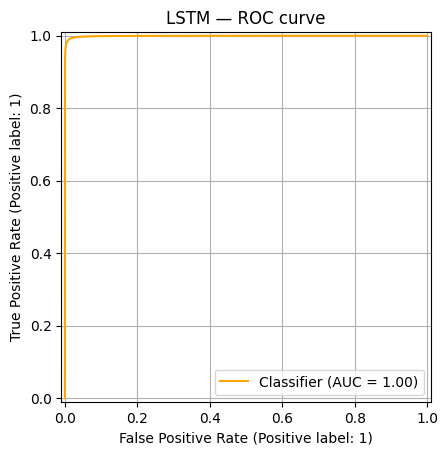

In [14]:
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay,
    roc_auc_score, average_precision_score
)

RocCurveDisplay.from_predictions(all_labels, all_probs_LSTM, color = "orange")
plt.title("LSTM — ROC curve")
plt.grid(True); plt.show()

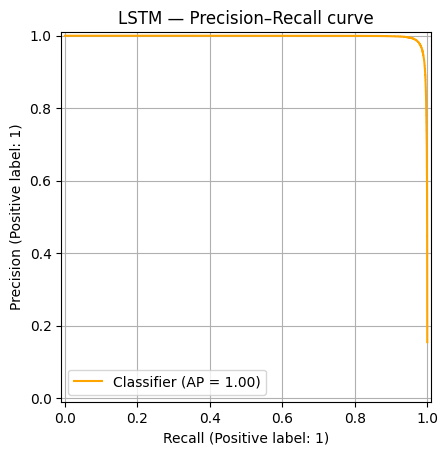

In [15]:
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay,
    roc_auc_score, average_precision_score
)


# 3) Plot Precision–Recall curve + report Average Precision (area under PR)
PrecisionRecallDisplay.from_predictions(all_labels, all_probs_LSTM, color = "orange")
plt.title("LSTM — Precision–Recall curve")
plt.grid(True); plt.show()


Text(0.5, 1.0, 'Calibration Curve for LSTM')

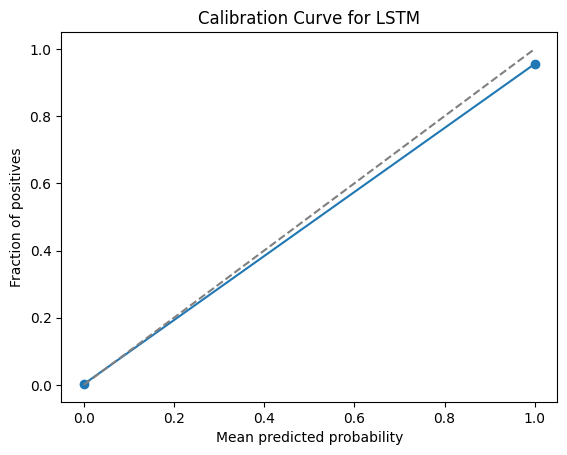

In [16]:
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(all_labels, all_preds_LSTM, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve for LSTM')

Text(0.5, 1.0, 'Normalized Confustion Matrix for LSTM')

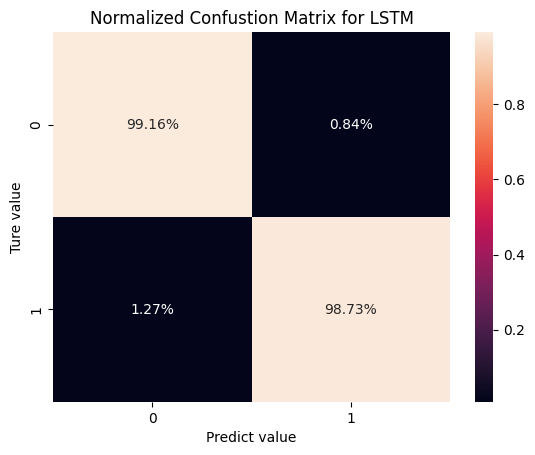

In [17]:
from sklearn.metrics import confusion_matrix

CM_LSTM = confusion_matrix(all_labels, all_preds_LSTM, normalize = 'true')
sns.heatmap(CM_LSTM, annot= True, fmt ='.2%', cbar = True)
plt.xlabel("Predict value")
plt.ylabel("Ture value")
plt.title("Normalized Confustion Matrix for LSTM")

## **GRU**

grid_search

In [ ]:
import torch
import torch.nn as nn
from sklearn.model_selection import ParameterGrid
from sklearn.metrics         import roc_auc_score


class GRUModel(nn.Module):
  def __init__(self, input_dim, hidden_dim, num_layers, dropout, output_dim = 1 ):
    super().__init__()
    self.input_dim = input_dim
    self.hidden_size = hidden_dim
    self.num_layers  = num_layers
    self.GRU = nn.GRU(input_dim, hidden_dim, num_layers, dropout = dropout, batch_first=True )
    self.fc = nn.Linear(hidden_dim, output_dim)

  def forward(self,x):
        out, _ = self.GRU(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

def train_and_evaluate(hidden_dim, num_layers, lr, dropout):

    model = GRUModel(
        input_dim=X_seq.shape[2],
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    pos_weight = torch.tensor([negatives / positives]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight= pos_weight)


    for epoch in range(5):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device).float().unsqueeze(-1)
            preds  = model(xb)
            loss   = criterion(preds, yb)
            optimizer.zero_grad(); loss.backward(); optimizer.step()


    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            probs = torch.sigmoid(model(xb).cpu())
            all_probs .extend(probs.numpy())
            all_labels.extend(yb.numpy())
    return roc_auc_score(all_labels, all_probs)

param_grid = {
  "hidden_dim": [64, 128, 256, 512],
  "num_layers": [3, 4, 5, 6],
  "lr":         [1e-2, 1e-3],
  "dropout" :   [0.1, 0.2, 0.3]
}


best_score = 0.0
best_params = None
for params in ParameterGrid(param_grid):
    auc = train_and_evaluate(**params)
    print(f"{params} → AUC={auc:.4f}")
    if auc > best_score:
        best_score, best_params = auc, params

print("Best:", best_params, "→", best_score)

{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.01, 'num_layers': 3} → AUC=0.7671
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.01, 'num_layers': 4} → AUC=0.7794
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.01, 'num_layers': 5} → AUC=0.7882
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.01, 'num_layers': 6} → AUC=0.7736
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.001, 'num_layers': 3} → AUC=0.8226
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.001, 'num_layers': 4} → AUC=0.8182
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.001, 'num_layers': 5} → AUC=0.8264
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.001, 'num_layers': 6} → AUC=0.8243
{'dropout': 0.1, 'hidden_dim': 128, 'lr': 0.01, 'num_layers': 3} → AUC=0.7681
{'dropout': 0.1, 'hidden_dim': 128, 'lr': 0.01, 'num_layers': 4} → AUC=0.7482
{'dropout': 0.1, 'hidden_dim': 128, 'lr': 0.01, 'num_layers': 5} → AUC=0.7658
{'dropout': 0.1, 'hidden_dim': 128, 'lr': 0.01, 'num_layers': 6} → AUC=0.5000
{'dropout': 0.1, 'hidden_dim': 128, 'lr': 0.001, 'num_layers': 3} → 

In [18]:
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, roc_auc_score

class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, output_dim=1):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_size = hidden_dim
        self.num_layers  = num_layers
        self.dropout = dropout
        self.GRU = nn.GRU(
            input_dim, hidden_dim, num_layers,
            dropout=dropout,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.GRU(x)          # [batch, seq_len, hidden_dim]
        out = out[:, -1, :]           # last time step
        out = self.fc(out)            # [batch, 1]
        return out

input_dim  = X_train.shape[2]
hidden_dim = 512
num_layers = 3
dropout = 0.2

model = GRUModel(input_dim, hidden_dim, num_layers, dropout).to(device)

pos_weight = torch.tensor([negatives / positives], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 100


for epoch in range(1, num_epochs + 1):
    # -------- TRAIN --------
    model.train()
    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    for x, y in train_loader:
        x = x.to(device, non_blocking=True)
        # BCEWithLogitsLoss expects float targets; match shape [B,1]
        y = y.to(device, non_blocking=True).float().unsqueeze(-1)

        logits = model(x)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        running_loss += loss.item() * bs

        with torch.no_grad():
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            running_correct += (preds == y).sum().item()
            total_samples += bs

    avg_train_loss = running_loss / len(train_ds)
    train_acc = running_correct / total_samples

    # -------- TEST / VALIDATION --------
    model.eval()
    test_running_loss = 0.0
    test_running_correct = 0
    test_total = 0

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True).float().unsqueeze(-1)

            logits = model(xb)
            loss = criterion(logits, yb)

            bs = xb.size(0)
            test_running_loss += loss.item() * bs

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            test_running_correct += (preds == yb).sum().item()
            test_total += bs

    avg_test_loss = test_running_loss / len(test_ds)
    test_acc = test_running_correct / test_total


    print(f"Epoch {epoch:3d} | "
          f"Train Loss: {avg_train_loss:.4f} Acc: {train_acc:.3f} | "
          f"Test Loss: {avg_test_loss:.4f} Acc: {test_acc:.3f}")

# -------- Final test metrics (AUC & accuracy) --------
model.eval()
all_preds_GRU, all_probs_GRU, all_labels = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device, non_blocking=True)
        logits = model(xb).cpu()
        probs_GRU  = torch.sigmoid(logits)
        preds_GRU  = (probs_GRU > 0.5).int()

        all_preds_GRU.extend(preds_GRU.numpy())
        all_probs_GRU.extend(probs_GRU.numpy())
        all_labels.extend(yb.numpy())  # yb from loader is on CPU here

acc = accuracy_score(all_labels, all_preds_GRU)
auc = roc_auc_score(all_labels, all_probs_GRU)
print(f"Final Test — Accuracy: {acc:.4f} | AUC: {auc:.4f}")


Epoch   1 | Train Loss: 0.9851 Acc: 0.673 | Test Loss: 0.9571 Acc: 0.567
Epoch   2 | Train Loss: 0.9012 Acc: 0.714 | Test Loss: 0.8822 Acc: 0.749
Epoch   3 | Train Loss: 0.8647 Acc: 0.729 | Test Loss: 0.8356 Acc: 0.767
Epoch   4 | Train Loss: 0.8240 Acc: 0.746 | Test Loss: 0.7759 Acc: 0.780
Epoch   5 | Train Loss: 0.7523 Acc: 0.782 | Test Loss: 0.6867 Acc: 0.811
Epoch   6 | Train Loss: 0.6423 Acc: 0.828 | Test Loss: 0.7182 Acc: 0.880
Epoch   7 | Train Loss: 0.5445 Acc: 0.861 | Test Loss: 0.4536 Acc: 0.883
Epoch   8 | Train Loss: 0.4667 Acc: 0.885 | Test Loss: 0.4013 Acc: 0.911
Epoch   9 | Train Loss: 0.4014 Acc: 0.904 | Test Loss: 0.3548 Acc: 0.928
Epoch  10 | Train Loss: 0.3542 Acc: 0.916 | Test Loss: 0.3443 Acc: 0.912
Epoch  11 | Train Loss: 0.3246 Acc: 0.923 | Test Loss: 0.2692 Acc: 0.934
Epoch  12 | Train Loss: 0.2905 Acc: 0.932 | Test Loss: 0.2583 Acc: 0.938
Epoch  13 | Train Loss: 0.2626 Acc: 0.938 | Test Loss: 0.5514 Acc: 0.885
Epoch  14 | Train Loss: 0.2697 Acc: 0.937 | Test Lo

In [19]:
from sklearn.metrics import classification_report

# Suppose all_labels and all_preds are your true and predicted labels:
report_GRU = classification_report(all_labels, all_preds_GRU, digits=4)
print(report_GRU)


              precision    recall  f1-score   support

         0.0     0.9961    0.9835    0.9898    519676
         1.0     0.9156    0.9788    0.9461     94876

    accuracy                         0.9828    614552
   macro avg     0.9558    0.9812    0.9680    614552
weighted avg     0.9837    0.9828    0.9830    614552



In [20]:
from sklearn.metrics import cohen_kappa_score

kappa_GRU = cohen_kappa_score(all_labels, all_preds_GRU)
print(f"Cohen’s kappa: {kappa_GRU:.3f}")

Cohen’s kappa: 0.936


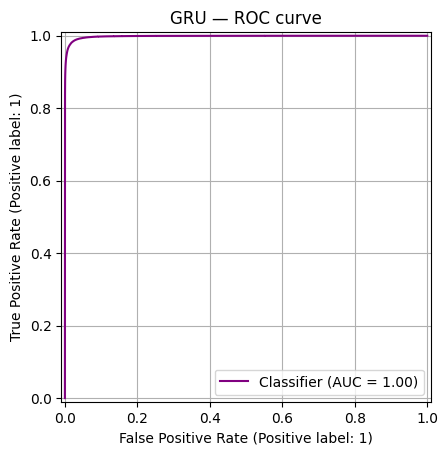

In [21]:
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay,
    roc_auc_score, average_precision_score
)

RocCurveDisplay.from_predictions(all_labels, all_probs_GRU, color = "purple")
plt.title("GRU — ROC curve")
plt.grid(True); plt.show()

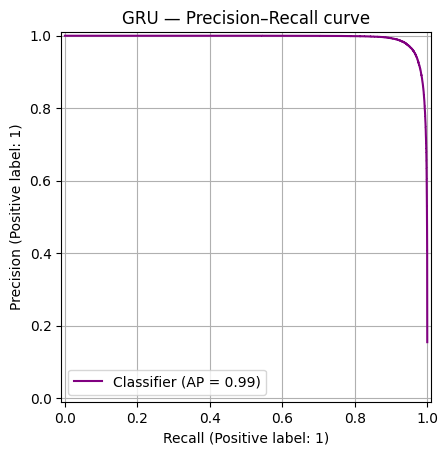

In [22]:
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay,
    roc_auc_score, average_precision_score
)


# 3) Plot Precision–Recall curve + report Average Precision (area under PR)
PrecisionRecallDisplay.from_predictions(all_labels, all_probs_GRU, color = "purple")
plt.title("GRU — Precision–Recall curve")
plt.grid(True); plt.show()


Text(0.5, 1.0, 'Calibration Curve for GRU')

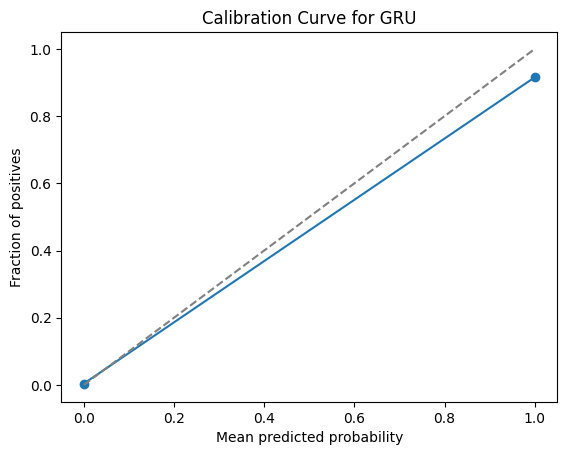

In [23]:
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(all_labels, all_preds_GRU, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve for GRU')

Text(0.5, 1.0, 'Normalized Confustion Matrix for GRU')

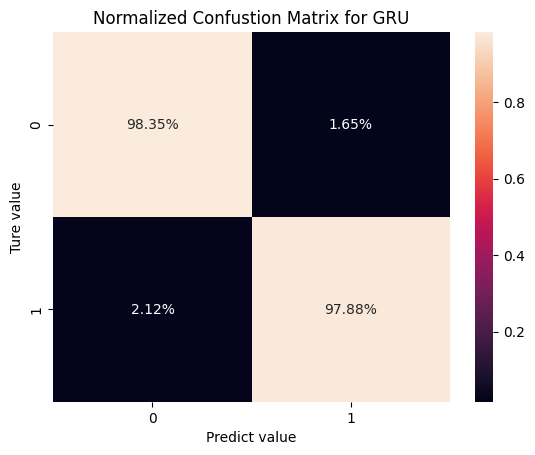

In [24]:
from sklearn.metrics import confusion_matrix

CM_GRU = confusion_matrix(all_labels, all_preds_GRU, normalize = 'true')
sns.heatmap(CM_GRU, annot= True, fmt = '.2%', cbar = True)
plt.xlabel("Predict value")
plt.ylabel("Ture value")
plt.title("Normalized Confustion Matrix for GRU")

## **Transformer**

Grid_Search

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score
from itertools import product
from copy import deepcopy

def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))
    weights = F.softmax(scores, dim=-1)
    return torch.matmul(weights, V), weights

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_k = d_model // num_heads
        self.num_heads = num_heads
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        B, T, _ = x.size()
        Q = self.w_q(x).view(B, T, self.num_heads, self.d_k).transpose(1,2)
        K = self.w_k(x).view(B, T, self.num_heads, self.d_k).transpose(1,2)
        V = self.w_v(x).view(B, T, self.num_heads, self.d_k).transpose(1,2)
        attn_out, _ = scaled_dot_product_attention(Q, K, V, mask)
        attn_out = attn_out.transpose(1,2).contiguous().view(B, T, -1)
        return self.w_o(attn_out)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :].to(x.device)

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.ReLU(), nn.Dropout(dropout), nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)

class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        y = self.self_attn(x, mask)
        x = self.norm1(x + self.dropout(y))
        z = self.ff(x)
        return self.norm2(x + self.dropout(z))

class MimicDataset(Dataset):
    def __init__(self, X_tensor, y_tensor):
        self.X = X_tensor
        self.y = y_tensor

    def __len__(self):
        return self.X.size(0)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class TabularEncoder(nn.Module):
    def __init__(self, feature_dim, d_model, num_layers, num_heads, d_ff, max_len):
        super().__init__()
        self.proj    = nn.Linear(feature_dim, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.layers  = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout=0.1)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        x = self.proj(x)
        x = self.pos_enc(x)
        for layer in self.layers:
            x = layer(x, mask)
        return x

class MortalityPredictor(nn.Module):
    def __init__(self, encoder, d_model, dropout):
        super().__init__()
        self.encoder    = encoder
        self.pooler     = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(d_model, 1))

    def forward(self, x, mask=None):
        h = self.encoder(x, mask)
        p = self.pooler(h.transpose(1,2)).squeeze(-1)
        return self.classifier(p).squeeze(-1)

seq_len     = X_train.shape[1]
feature_dim = X_train.shape[2]

param_grid = {
    'd_model':   [128, 256],
    'num_heads': [2, 4, 8],
    'num_layers': [2, 4, 6],
    'd_ff':      [256, 516],
    'dropout':   [0.1, 0.2],
    'lr':        [1e-2, 1e-3]
}
param_list = list(product(
    param_grid['d_model'],
    param_grid['num_heads'],
    param_grid['num_layers'],
    param_grid['d_ff'],
    param_grid['dropout'],
    param_grid['lr']
))

pos_weight = torch.tensor([negatives / positives]).to(device)

best_auc = 0.0
best_params = None
results = []

for i, (d_model, num_heads, num_layers, d_ff, dropout, lr) in enumerate(param_list):
    print(f"\nGrid {i+1}/{len(param_list)}: d_model={d_model}, num_heads={num_heads}, num_layers={num_layers}, d_ff={d_ff}, dropout={dropout}, lr={lr}")

    encoder = TabularEncoder(feature_dim, d_model, num_layers, num_heads, d_ff, max_len=seq_len)
    model = MortalityPredictor(encoder, d_model, dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # Train (few epochs for grid search)
    for epoch in range(1, 4):
        model.train()
        for X, y in train_loader:
            X = X.to(device)
            y = y.to(device).float()
            optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    model.eval()
    all_probs_T, all_labels = [], []
    with torch.no_grad():
        for X, y in test_loader:
            X = X.to(device)
            y = y.to(device).float()
            logits = model(X)
            probs = torch.sigmoid(logits)
            all_probs_T.append(probs.cpu())
            all_labels.append(y.cpu())
    all_probs_T = torch.cat(all_probs_T).numpy()
    all_labels = torch.cat(all_labels).numpy()
    auc = roc_auc_score(all_labels, all_probs_T)
    print(f"Validation/Test AUC: {auc:.4f}")

    results.append(((d_model, num_heads, num_layers, d_ff, dropout, lr), auc))
    if auc > best_auc:
        best_auc = auc
        best_params = (d_model, num_heads, num_layers, d_ff, dropout, lr)
        best_model = deepcopy(model.state_dict())

print("\n=== Grid Search Results ===")
for params, auc in results:
    print(f"Params: {params}, AUC: {auc:.4f}")

print(f"\nBest Params: {best_params}, Best AUC: {best_auc:.4f}")



Grid 1/144: d_model=128, num_heads=2, num_layers=2, d_ff=256, dropout=0.1, lr=0.01
Validation/Test AUC: 0.6334

Grid 2/144: d_model=128, num_heads=2, num_layers=2, d_ff=256, dropout=0.1, lr=0.001
Validation/Test AUC: 0.8247

Grid 3/144: d_model=128, num_heads=2, num_layers=2, d_ff=256, dropout=0.2, lr=0.01
Validation/Test AUC: 0.5658

Grid 4/144: d_model=128, num_heads=2, num_layers=2, d_ff=256, dropout=0.2, lr=0.001
Validation/Test AUC: 0.8165

Grid 5/144: d_model=128, num_heads=2, num_layers=2, d_ff=516, dropout=0.1, lr=0.01
Validation/Test AUC: 0.4815

Grid 6/144: d_model=128, num_heads=2, num_layers=2, d_ff=516, dropout=0.1, lr=0.001
Validation/Test AUC: 0.8340

Grid 7/144: d_model=128, num_heads=2, num_layers=2, d_ff=516, dropout=0.2, lr=0.01
Validation/Test AUC: 0.5031

Grid 8/144: d_model=128, num_heads=2, num_layers=2, d_ff=516, dropout=0.2, lr=0.001
Validation/Test AUC: 0.8230

Grid 9/144: d_model=128, num_heads=2, num_layers=4, d_ff=256, dropout=0.1, lr=0.01
Validation/Test 

In [25]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score
from torch.nn import CrossEntropyLoss

# ==== Core Transformer Components ==== #

def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))
    weights = F.softmax(scores, dim=-1)
    return torch.matmul(weights, V), weights

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_k = d_model // num_heads
        self.num_heads = num_heads
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        B, T, _ = x.size()
        Q = self.w_q(x).view(B, T, self.num_heads, self.d_k).transpose(1,2)
        K = self.w_k(x).view(B, T, self.num_heads, self.d_k).transpose(1,2)
        V = self.w_v(x).view(B, T, self.num_heads, self.d_k).transpose(1,2)
        attn_out, _ = scaled_dot_product_attention(Q, K, V, mask)
        attn_out = attn_out.transpose(1,2).contiguous().view(B, T, -1)
        return self.w_o(attn_out)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        # register as buffer so it moves with .to(device) and is saved in state_dict
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)

class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        y = self.self_attn(x, mask)
        x = self.norm1(x + self.dropout(y))
        z = self.ff(x)
        return self.norm2(x + self.dropout(z))

class MimicDataset(Dataset):
    def __init__(self, X_tensor, y_tensor):
        self.X = X_tensor
        self.y = y_tensor

    def __len__(self):
        return self.X.size(0)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class TabularEncoder(nn.Module):
    def __init__(self, feature_dim, d_model, num_layers, num_heads, d_ff, max_len):
        super().__init__()
        self.proj    = nn.Linear(feature_dim, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.layers  = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout=0.1)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        x = self.proj(x)
        x = self.pos_enc(x)
        for layer in self.layers:
            x = layer(x, mask)
        return x

class MortalityPredictor(nn.Module):
    def __init__(self, encoder, d_model, dropout):
        super().__init__()
        self.encoder    = encoder
        self.pooler     = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(d_model, 1))

    def forward(self, x, mask=None):
        h = self.encoder(x, mask)                 # [B, T, d_model]
        p = self.pooler(h.transpose(1,2)).squeeze(-1)  # [B, d_model]
        return self.classifier(p).squeeze(-1)     # [B]

# ==== Training & Final Test ==== #
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Assume train_loader, test_loader, X_train are defined externally
seq_len     = X_train.shape[1]
feature_dim = X_train.shape[2]

# Hyperparameters
hparams = {
    'd_model': 128,
    'num_heads': 2,
    'num_layers': 4,
    'd_ff': 512,
    'dropout': 0.1,
    'lr': 1e-3,
    'epochs': 100
}

encoder = TabularEncoder(
    feature_dim,
    hparams['d_model'],
    hparams['num_layers'],
    hparams['num_heads'],
    hparams['d_ff'],
    max_len=seq_len
)

model     = MortalityPredictor(encoder, hparams['d_model'], hparams['dropout']).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=hparams['lr'], weight_decay=1e-5)

# class imbalance
pos_weight = torch.tensor([2077431 / 380775], dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


for epoch in range(1, hparams['epochs']+1):
    # ===== TRAIN =====
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X, y in train_loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True).float()

        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)                    # BCEWithLogitsLoss
        loss.backward()
        # optional: gradient clipping for stability
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        bs = X.size(0)
        running_loss += loss.item() * bs
        with torch.no_grad():
            preds = (torch.sigmoid(logits) > 0.5).int()
            correct += (preds == y.int()).sum().item()
            total += bs

    avg_train_loss = running_loss / total
    train_acc = correct / total

    # ===== TEST / EVAL =====
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for X, y in test_loader:
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True).float()

            logits = model(X)
            loss = criterion(logits, y)

            bs = X.size(0)
            test_loss += loss.item() * bs

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).int()
            test_correct += (preds == y.int()).sum().item()
            test_total += bs

    avg_test_loss = test_loss / test_total
    test_acc = test_correct / test_total

    print(f"Epoch {epoch:03d} | "
          f"Train Loss {avg_train_loss:.4f} Acc {train_acc:.3f} | "
          f"Test Loss {avg_test_loss:.4f} Acc {test_acc:.3f}")

# ===== Final test evaluation (kept) =====
model.eval()
test_loss = 0.0
all_probs_T, all_preds_T, all_labels = [], [], []
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True).float()
        logits = model(X)
        loss = criterion(logits, y)
        test_loss += loss.item() * X.size(0)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).int()
        all_probs_T.append(probs.cpu())
        all_preds_T.append(preds.cpu())
        all_labels.append(y.cpu())

N = len(test_loader.dataset)
all_probs_T  = torch.cat(all_probs_T).numpy()
all_preds_T  = torch.cat(all_preds_T).numpy()
all_labels   = torch.cat(all_labels).numpy()
print(f"Test Loss={test_loss/N:.4f} | Test Acc={accuracy_score(all_labels, all_preds_T):.4f} | Test AUC={roc_auc_score(all_labels, all_probs_T):.4f}")


Epoch 001 | Train Loss 1.0726 Acc 0.619 | Test Loss 0.9517 Acc 0.744
Epoch 002 | Train Loss 0.9367 Acc 0.695 | Test Loss 0.8915 Acc 0.714
Epoch 003 | Train Loss 0.8857 Acc 0.725 | Test Loss 0.8462 Acc 0.750
Epoch 004 | Train Loss 0.8413 Acc 0.742 | Test Loss 0.8012 Acc 0.770
Epoch 005 | Train Loss 0.7886 Acc 0.767 | Test Loss 0.7397 Acc 0.781
Epoch 006 | Train Loss 0.7281 Acc 0.792 | Test Loss 0.7474 Acc 0.748
Epoch 007 | Train Loss 0.6849 Acc 0.811 | Test Loss 0.6677 Acc 0.821
Epoch 008 | Train Loss 0.6401 Acc 0.827 | Test Loss 0.6046 Acc 0.818
Epoch 009 | Train Loss 0.5996 Acc 0.841 | Test Loss 0.5419 Acc 0.859
Epoch 010 | Train Loss 0.5566 Acc 0.856 | Test Loss 0.5236 Acc 0.876
Epoch 011 | Train Loss 0.5264 Acc 0.866 | Test Loss 0.5017 Acc 0.860
Epoch 012 | Train Loss 0.4945 Acc 0.876 | Test Loss 0.4605 Acc 0.876
Epoch 013 | Train Loss 0.4689 Acc 0.884 | Test Loss 0.4271 Acc 0.913
Epoch 014 | Train Loss 0.4451 Acc 0.890 | Test Loss 0.4326 Acc 0.863
Epoch 015 | Train Loss 0.4239 Acc 

In [26]:
from sklearn.metrics import classification_report

# Suppose all_labels and all_preds are your true and predicted labels:
report_transformer = classification_report(all_labels, all_preds_T, digits=4)
print(report_transformer)

              precision    recall  f1-score   support

         0.0     0.9956    0.9796    0.9876    519676
         1.0     0.8975    0.9762    0.9352     94876

    accuracy                         0.9791    614552
   macro avg     0.9465    0.9779    0.9614    614552
weighted avg     0.9804    0.9791    0.9795    614552



In [27]:
from sklearn.metrics import cohen_kappa_score

kappa_T = cohen_kappa_score(all_labels, all_preds_T)
print(f"Cohen’s kappa: {kappa_T:.3f}")

Cohen’s kappa: 0.923


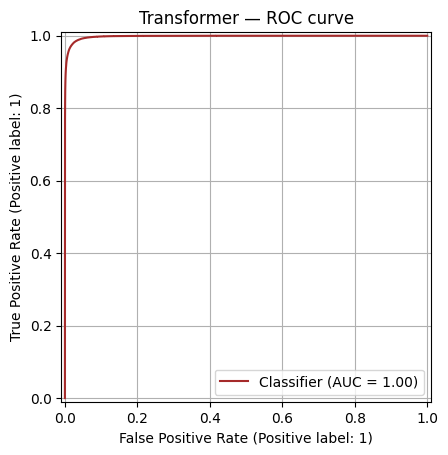

In [28]:
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay,
    roc_auc_score, average_precision_score
)

RocCurveDisplay.from_predictions(all_labels, all_probs_T, color = "Brown")
plt.title("Transformer — ROC curve")
plt.grid(True); plt.show()

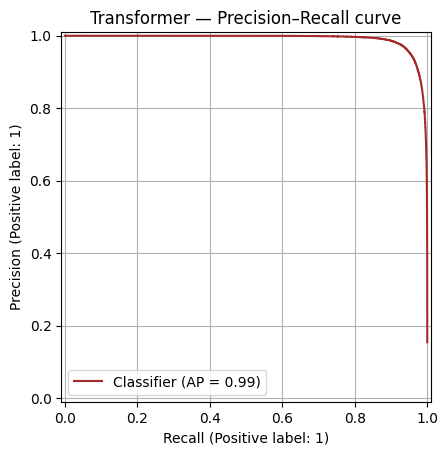

In [29]:
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay,
    roc_auc_score, average_precision_score
)


# 3) Plot Precision–Recall curve + report Average Precision (area under PR)
PrecisionRecallDisplay.from_predictions(all_labels, all_probs_T,color = "Brown")
plt.title("Transformer — Precision–Recall curve")
plt.grid(True); plt.show()

Text(0.5, 1.0, 'Calibration Curve for Transformer')

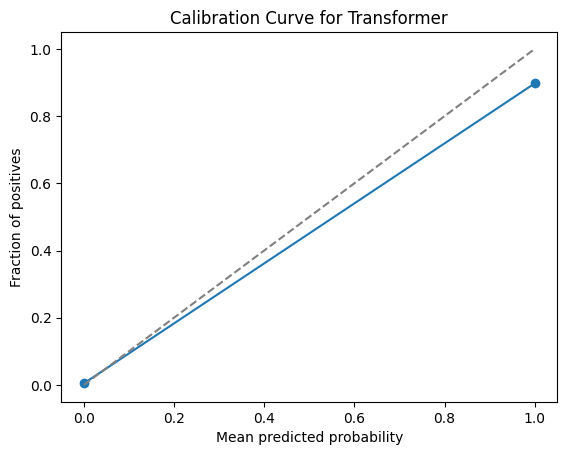

In [30]:
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(all_labels, all_preds_T, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve for Transformer')

Text(0.5, 1.0, 'Normalized Confustion Matrix for Tranformer')

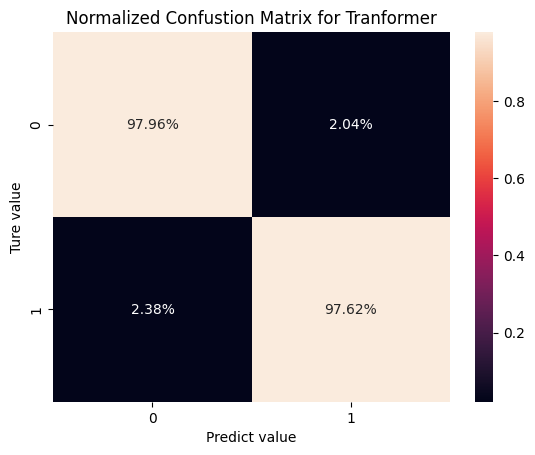

In [31]:
from sklearn.metrics import confusion_matrix

CM_T = confusion_matrix(all_labels, all_preds_T, normalize = 'true')
sns.heatmap(CM_T, annot= True, fmt = '.2%', cbar = True)
plt.xlabel("Predict value")
plt.ylabel("Ture value")
plt.title("Normalized Confustion Matrix for Tranformer")